# Fase 2 — Score Regional Municipal

**Proyecto:** Crédito Remesa Jalisco — Modelos de Crédito (ITESO)

Este notebook valida el score regional municipal construido por `08_construir_score_regional.py` y realiza visualizaciones diagnósticas. Las salidas se usan para el reporte final APA7.

## Estructura
1. Carga y validación básica
2. Distribución del score y sub-scores
3. Top y bottom municipios
4. Correlaciones entre componentes
5. Validación contra categorizaciones oficiales (CONAPO IIM y Marginación)
6. Mapa de Jalisco coloreado por score (si geopandas está disponible)


## 1. Carga y validación básica

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FEATURES_CSV = PROJECT_ROOT / 'data' / 'processed' / 'jalisco_municipal_features.csv'
SCORE_CSV = PROJECT_ROOT / 'data' / 'processed' / 'jalisco_score_regional.csv'

df_feat = pd.read_csv(FEATURES_CSV)
df_score = pd.read_csv(SCORE_CSV)

print(f'Features: {df_feat.shape}')
print(f'Scores:   {df_score.shape}')
df_score.head(10)

Features: (124, 37)
Scores:   (124, 8)


,cve_municipio,municipio,sub_score_capacidad_pago,sub_score_calidad_socioeconomica,sub_score_intensidad_migratoria,score_regional,gim_dp2,gm_2020
0,14039,Guadalajara,0.669373,0.683461,0.977003,0.736534,Bajo,Muy bajo
1,14120,Zapopan,0.536126,0.708200,0.955355,0.688801,Bajo,Muy bajo
2,14067,Puerto Vallarta,0.411877,0.650265,0.951796,0.615216,Bajo,Muy bajo
3,14098,San Pedro Tlaquepaque,0.412938,0.619987,0.997768,0.612723,Muy bajo,Muy bajo
4,14023,Zapotlán el Grande,0.377042,0.658718,0.967602,0.607824,Bajo,Muy bajo
5,14101,Tonalá,0.410010,0.592742,0.959547,0.593010,Bajo,Muy bajo
6,14097,Tlajomulco de Zúñiga,0.380301,0.599679,1.000000,0.591992,Muy bajo,Muy bajo
7,14093,Tepatitlán de Morelos,0.422189,0.570067,0.953401,0.587583,Bajo,Muy bajo
8,14015,Autlán de Navarro,0.447265,0.610866,0.742381,0.571728,Medio,Muy bajo
9,14063,Ocotlán,0.399335,0.579251,0.893632,0.570161,Bajo,Muy bajo


In [2]:
# Asegurar que cve_municipio sea string con relleno de ceros para mantener formato '14001'
df_feat['cve_municipio'] = df_feat['cve_municipio'].astype(str).str.zfill(5)
df_score['cve_municipio'] = df_score['cve_municipio'].astype(str).str.zfill(5)

# Resumen estadístico del score
df_score[['sub_score_capacidad_pago',
          'sub_score_calidad_socioeconomica',
          'sub_score_intensidad_migratoria',
          'score_regional']].describe()

,sub_score_capacidad_pago,sub_score_calidad_socioeconomica,sub_score_intensidad_migratoria,score_regional
count,124.000000,124.000000,124.000000,124.000000
mean,0.422899,0.470893,0.642781,0.486073
std,0.074922,0.084451,0.224993,0.065360
min,0.150648,0.170749,0.000000,0.322157
25%,0.385970,0.424610,0.507630,0.449522
50%,0.421534,0.472921,0.650439,0.485247
75%,0.463801,0.522224,0.837049,0.521232
max,0.669373,0.708200,1.000000,0.736534


## 2. Distribución del score y sub-scores

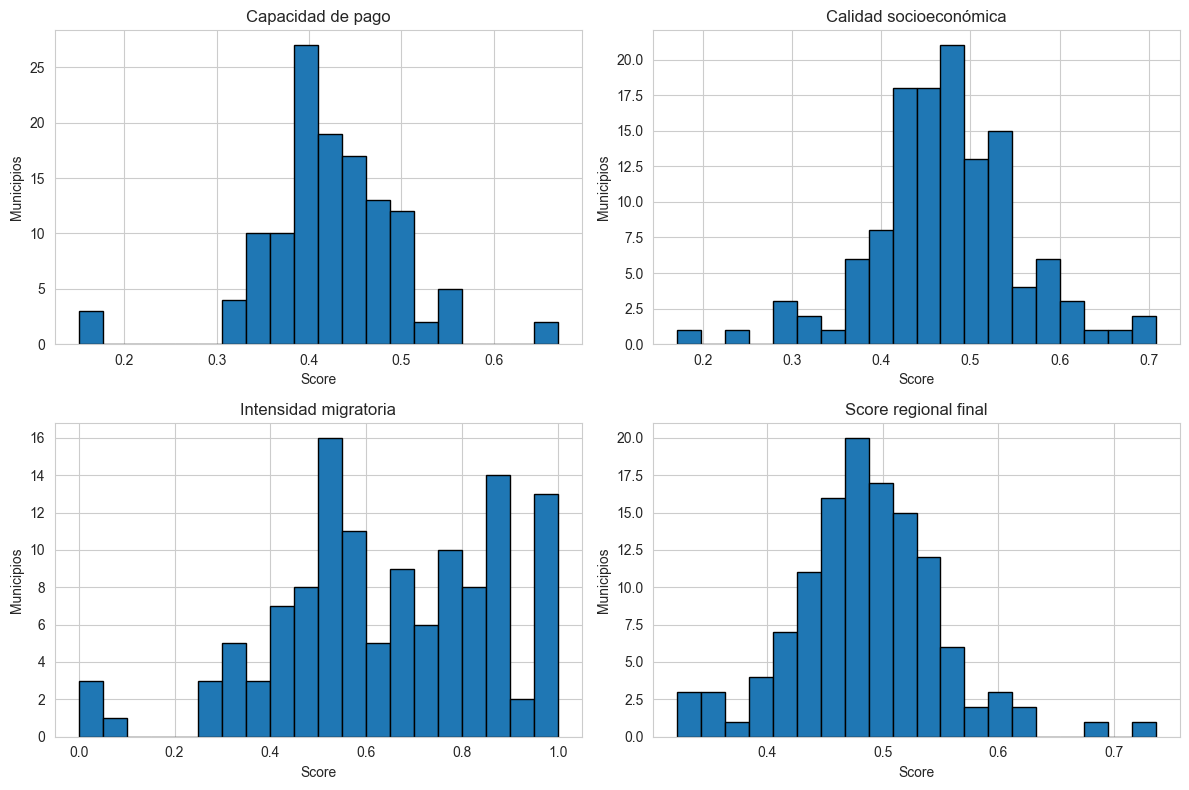

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
score_cols = [
    ('sub_score_capacidad_pago', 'Capacidad de pago'),
    ('sub_score_calidad_socioeconomica', 'Calidad socioeconómica'),
    ('sub_score_intensidad_migratoria', 'Intensidad migratoria'),
    ('score_regional', 'Score regional final'),
]
for ax, (col, title) in zip(axes.flat, score_cols):
    ax.hist(df_score[col].dropna(), bins=20, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Municipios')
plt.tight_layout()
plt.show()

## 3. Top y bottom municipios

In [4]:
# Top 15 y bottom 15 lado a lado
top15 = df_score.nlargest(15, 'score_regional')[['cve_municipio', 'municipio', 'score_regional', 'gim_dp2', 'gm_2020']]
bot15 = df_score.nsmallest(15, 'score_regional')[['cve_municipio', 'municipio', 'score_regional', 'gim_dp2', 'gm_2020']]

print('TOP 15 — mejor score regional:')
print(top15.to_string(index=False))
print('\nBOTTOM 15 — peor score regional:')
print(bot15.to_string(index=False))

TOP 15 — mejor score regional:
cve_municipio             municipio  score_regional  gim_dp2  gm_2020
        14039           Guadalajara        0.736534     Bajo Muy bajo
        14120               Zapopan        0.688801     Bajo Muy bajo
        14067       Puerto Vallarta        0.615216     Bajo Muy bajo
        14098 San Pedro Tlaquepaque        0.612723 Muy bajo Muy bajo
        14023    Zapotlán el Grande        0.607824     Bajo Muy bajo
        14101                Tonalá        0.593010     Bajo Muy bajo
        14097  Tlajomulco de Zúñiga        0.591992 Muy bajo Muy bajo
        14093 Tepatitlán de Morelos        0.587583     Bajo Muy bajo
        14015     Autlán de Navarro        0.571728    Medio Muy bajo
        14063               Ocotlán        0.570161     Bajo Muy bajo
        14037             El Grullo        0.569588    Medio Muy bajo
        14082                Sayula        0.567096     Bajo Muy bajo
        14030               Chapala        0.564803    Medi

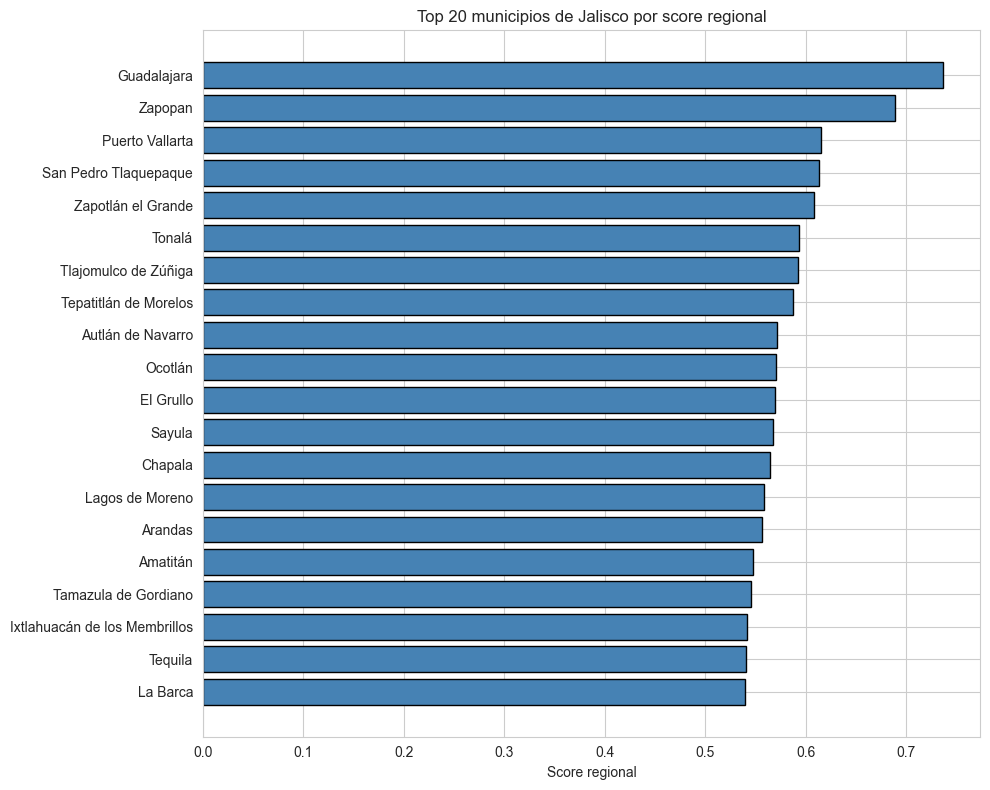

In [5]:
# Visualización barchart top 20
top20 = df_score.nlargest(20, 'score_regional')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['municipio'][::-1], top20['score_regional'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Score regional')
ax.set_title('Top 20 municipios de Jalisco por score regional')
plt.tight_layout()
plt.show()

## 4. Correlaciones entre componentes

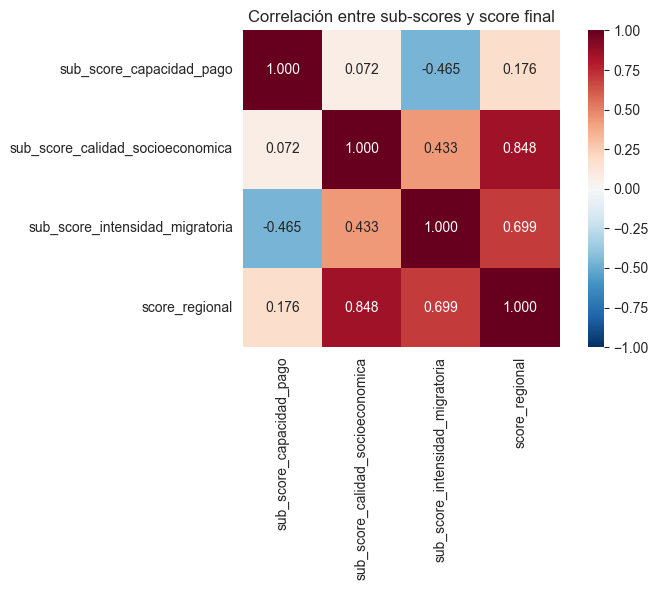

Notas interpretativas:
- Si capacidad_pago y calidad_socio están altamente correlacionados (>0.7), conviene revisar pesos.
- Si intensidad migratoria está negativamente correlacionada con calidad_socio, refleja el patrón típico (más migración en zonas más marginadas).


In [6]:
corr_cols = [
    'sub_score_capacidad_pago',
    'sub_score_calidad_socioeconomica',
    'sub_score_intensidad_migratoria',
    'score_regional',
]
corr_mat = df_score[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlación entre sub-scores y score final')
plt.tight_layout()
plt.show()

print('Notas interpretativas:')
print('- Si capacidad_pago y calidad_socio están altamente correlacionados (>0.7), conviene revisar pesos.')
print('- Si intensidad migratoria está negativamente correlacionada con calidad_socio, refleja el patrón típico (más migración en zonas más marginadas).')

## 5. Validación contra categorizaciones oficiales

C:\Users\david\AppData\Local\Temp\ipykernel_6592\280669459.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_score, x='gm_2020_ord', y='score_regional', ax=ax, palette='RdYlGn_r')


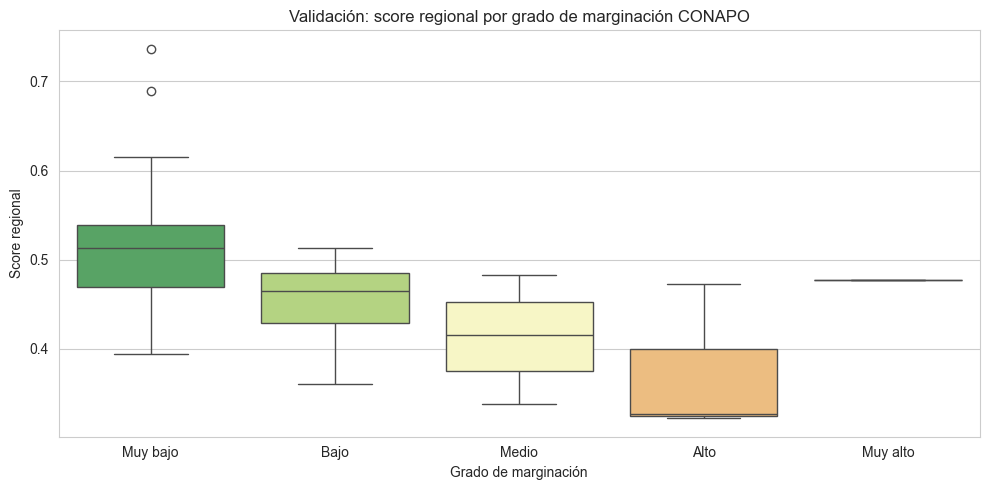


Media del score por grado de marginación:
               mean  count
gm_2020_ord               
Muy bajo     0.5127     77
Bajo         0.4533     34
Medio        0.4128      8
Alto         0.3739      3
Muy alto     0.4773      2


In [7]:
# Validación 1: score_regional por grado de marginación CONAPO
# Esperado: Muy bajo > Bajo > Medio > Alto > Muy alto
orden_marg = ['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto']
df_score['gm_2020_ord'] = pd.Categorical(df_score['gm_2020'], categories=orden_marg, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_score, x='gm_2020_ord', y='score_regional', ax=ax, palette='RdYlGn_r')
ax.set_title('Validación: score regional por grado de marginación CONAPO')
ax.set_xlabel('Grado de marginación')
ax.set_ylabel('Score regional')
plt.tight_layout()
plt.show()

print('\nMedia del score por grado de marginación:')
print(df_score.groupby('gm_2020_ord', observed=True)['score_regional'].agg(['mean', 'count']).round(4))

C:\Users\david\AppData\Local\Temp\ipykernel_6592\1609410366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_score, x='gim_dp2_ord', y='sub_score_capacidad_pago', ax=ax, palette='Blues')


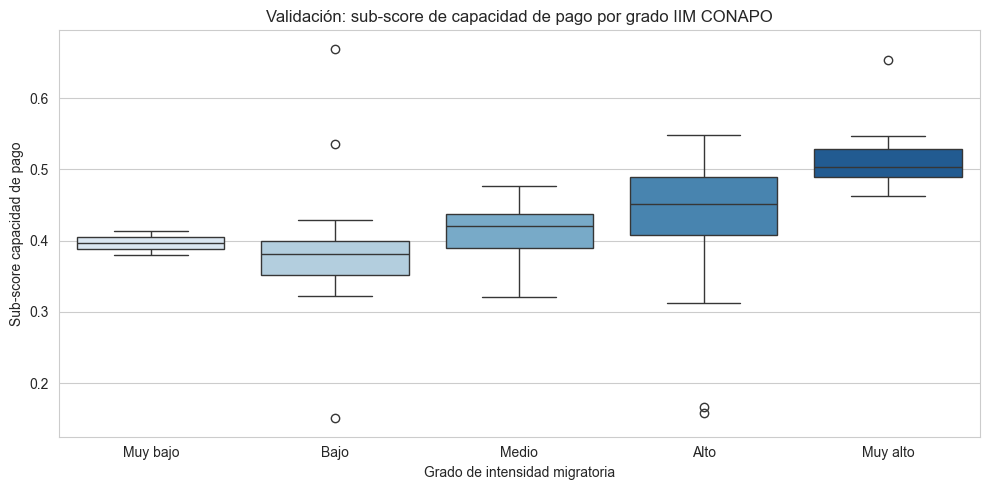


Media del sub-score capacidad_pago por grado IIM:
               mean  count
gim_dp2_ord               
Muy bajo     0.3966      2
Bajo         0.3855     30
Medio        0.4115     33
Alto         0.4393     52
Muy alto     0.5228      7


In [8]:
# Validación 2: sub_score_capacidad_pago por grado de IIM
# Esperado: a mayor IIM → mayor capacidad de pago (más viviendas con remesas)
df_score['gim_dp2_ord'] = pd.Categorical(df_score['gim_dp2'], categories=orden_marg, ordered=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_score, x='gim_dp2_ord', y='sub_score_capacidad_pago', ax=ax, palette='Blues')
ax.set_title('Validación: sub-score de capacidad de pago por grado IIM CONAPO')
ax.set_xlabel('Grado de intensidad migratoria')
ax.set_ylabel('Sub-score capacidad de pago')
plt.tight_layout()
plt.show()

print('\nMedia del sub-score capacidad_pago por grado IIM:')
print(df_score.groupby('gim_dp2_ord', observed=True)['sub_score_capacidad_pago'].agg(['mean', 'count']).round(4))

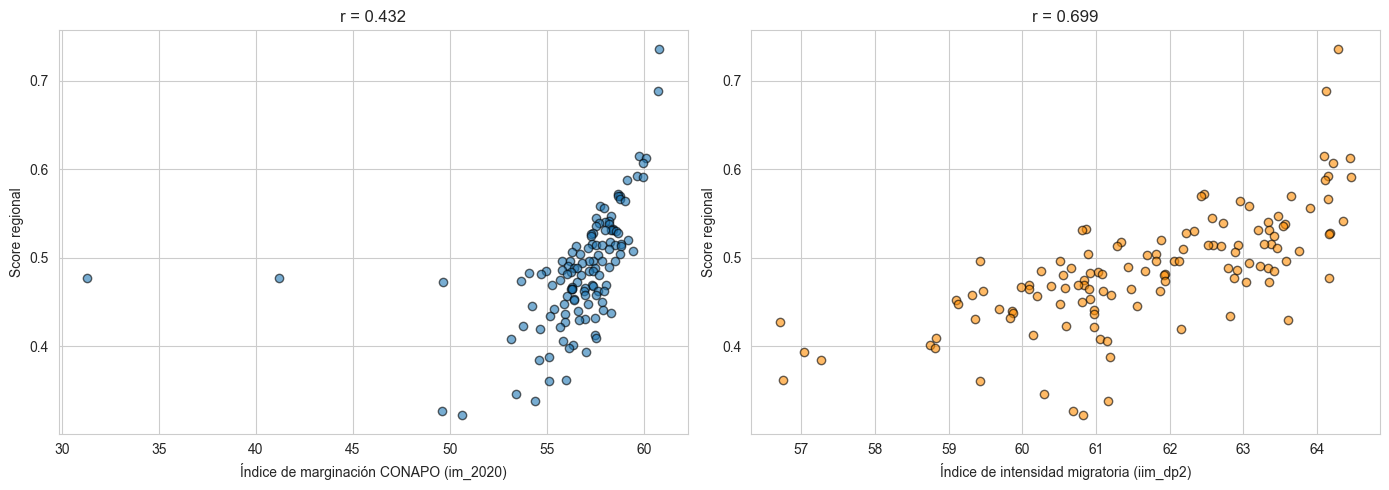

In [9]:
# Correlación numérica score_regional vs marginación continua y IIM continuo
df_merged = df_score.merge(
    df_feat[['cve_municipio', 'im_2020', 'iim_dp2', 'pob_total']],
    on='cve_municipio',
    how='left',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_merged['im_2020'], df_merged['score_regional'], alpha=0.6, edgecolor='black')
axes[0].set_xlabel('Índice de marginación CONAPO (im_2020)')
axes[0].set_ylabel('Score regional')
axes[0].set_title(f"r = {df_merged[['im_2020', 'score_regional']].corr().iloc[0, 1]:.3f}")

axes[1].scatter(df_merged['iim_dp2'], df_merged['score_regional'], alpha=0.6, edgecolor='black', color='darkorange')
axes[1].set_xlabel('Índice de intensidad migratoria (iim_dp2)')
axes[1].set_ylabel('Score regional')
axes[1].set_title(f"r = {df_merged[['iim_dp2', 'score_regional']].corr().iloc[0, 1]:.3f}")

plt.tight_layout()
plt.show()

## 6. Mapa de Jalisco coloreado por score (opcional)

Si tienes el archivo `municipios_jalisco_geometrias.geojson` en `data/raw/`, esta celda produce un mapa coroplético. Si no, salta esta celda.

Columnas del GeoJSON: ['id', 'ADM0_CODE', 'ADM0_NAME', 'ADM1_CODE', 'ADM1_NAME', 'ADM2_CODE', 'ADM2_NAME', 'DISP_AREA', 'EXP2_YEAR', 'STATUS', 'STR2_YEAR', 'Shape_Area', 'Shape_Leng', 'geometry']
Usando columna 'ADM2_CODE' como llave de cruce con el catálogo.


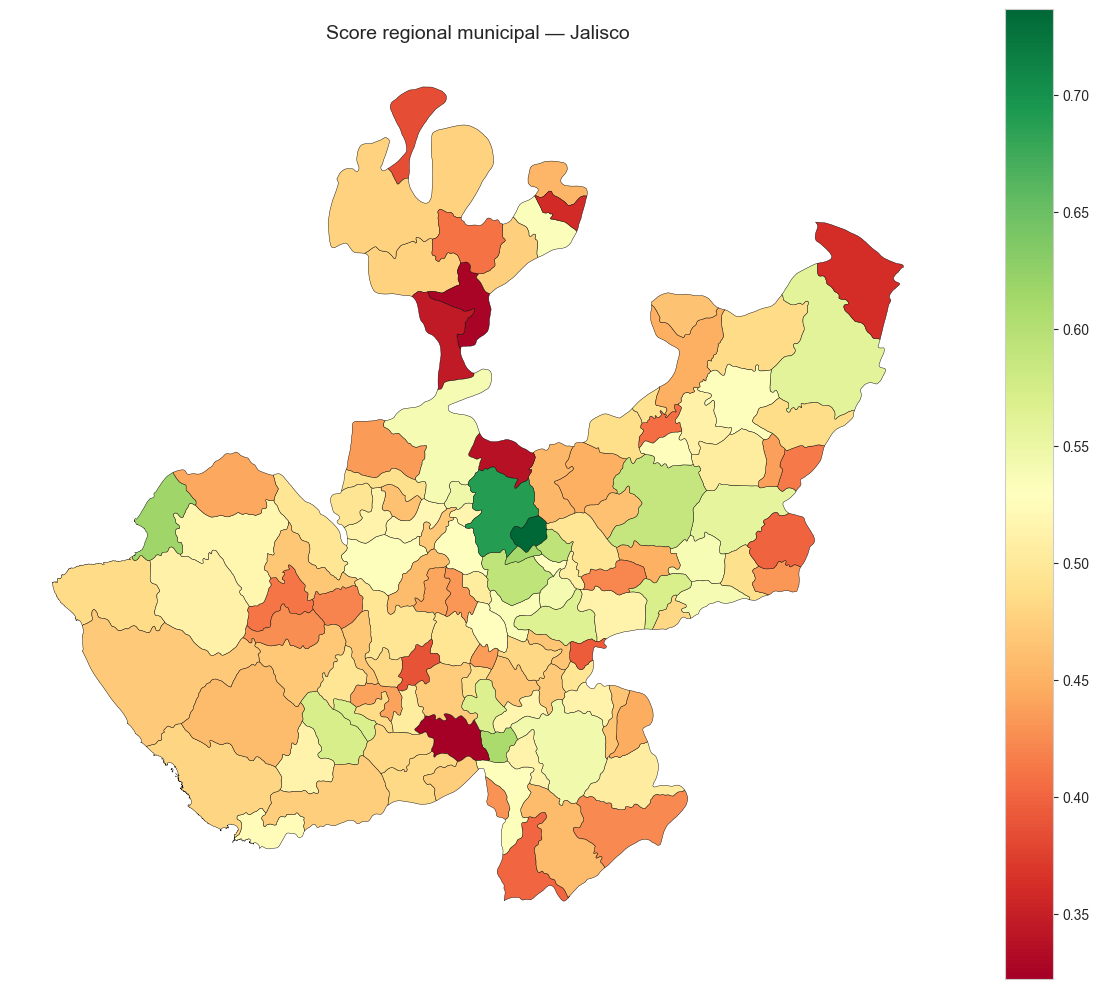

In [10]:
GEOJSON = PROJECT_ROOT / 'data' / 'raw' / 'municipios_jalisco_geometrias.geojson'

if not GEOJSON.exists():
    print(f'GeoJSON de geometrías no encontrado en {GEOJSON.relative_to(PROJECT_ROOT)}.')
    print('El mapa es opcional. Para habilitarlo, descarga las geometrías municipales')
    print('de Jalisco (FAO GAUL o INEGI Marco Geoestadístico) y guárdalas en esa ruta.')
else:
    try:
        import geopandas as gpd
        gdf = gpd.read_file(GEOJSON)
        print('Columnas del GeoJSON:', gdf.columns.tolist())
        
        # Detectar dinámicamente la columna que contiene la clave del catálogo FAO
        candidatos_clave = ['adm2_code', 'ADM2_CODE', 'adm2_id', 'ADM2_ID', 'GID_2', 'gid_2']
        col_clave = next((c for c in candidatos_clave if c in gdf.columns), None)
        
        if col_clave is None:
            print(f'No se detectó automáticamente la columna de clave. Columnas disponibles: {gdf.columns.tolist()}')
            print('Edita esta celda y ajusta el merge manualmente.')
        else:
            print(f'Usando columna {col_clave!r} como llave de cruce con el catálogo.')
            catalog = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'municipios_jalisco_catalogo.csv')
            catalog['cve_municipio'] = catalog['cve_municipio'].astype(str).str.zfill(5)
            
            # Asegurar tipo compatible para el merge
            gdf[col_clave] = gdf[col_clave].astype(str)
            catalog['adm2_code_fao'] = catalog['adm2_code_fao'].astype(str)
            
            gdf = gdf.merge(catalog[['adm2_code_fao', 'cve_municipio']],
                            left_on=col_clave, right_on='adm2_code_fao', how='left')
            gdf = gdf.merge(df_score[['cve_municipio', 'score_regional']],
                            on='cve_municipio', how='left')
            
            fig, ax = plt.subplots(figsize=(12, 10))
            gdf.plot(column='score_regional', ax=ax, legend=True,
                     cmap='RdYlGn', edgecolor='black', linewidth=0.3,
                     missing_kwds={'color': 'lightgrey', 'label': 'Sin dato'})
            ax.set_title('Score regional municipal — Jalisco', fontsize=14)
            ax.axis('off')
            plt.tight_layout()
            plt.show()
    except ImportError:
        print('geopandas no está instalado. pip install geopandas para habilitar el mapa.')
    except Exception as e:
        print(f'Error generando el mapa: {type(e).__name__}: {e}')
        print('Salta esta celda; el mapa es opcional para Fase 2.')

## 7. Resumen ejecutivo

Esta sección recopila los hallazgos principales para incluir en el reporte APA7.

In [11]:
# Quintiles de score
df_score['quintil_score'] = pd.qcut(df_score['score_regional'], q=5, 
                                     labels=['Q1 (peor)', 'Q2', 'Q3', 'Q4', 'Q5 (mejor)'])

print('Distribución de municipios por quintil:')
print(df_score['quintil_score'].value_counts().sort_index())

# Tabla cruzada quintil_score x grado_marginacion
print('\nMatriz de validación (quintil score × grado marginación):')
print(pd.crosstab(df_score['quintil_score'], df_score['gm_2020_ord'], dropna=False))

Distribución de municipios por quintil:
quintil_score
Q1 (peor)     25
Q2            25
Q3            24
Q4            25
Q5 (mejor)    25
Name: count, dtype: int64

Matriz de validación (quintil score × grado marginación):
gm_2020_ord    Muy bajo  Bajo  Medio  Alto  Muy alto
quintil_score                                       
Q1 (peor)             7    11      5     2         0
Q2                   14    10      1     0         0
Q3                    9    10      2     1         2
Q4                   22     3      0     0         0
Q5 (mejor)           25     0      0     0         0


## 8. Interpretación metodológica del score (para reporte APA7)

El score regional municipal del Componente 1 mide la **favorabilidad estructural del entorno regional para sostener un crédito hipotecario**, no la concentración de hogares receptores de remesas. Esta distinción es central para la coherencia del modelo híbrido propuesto:

1. **El Componente 1** captura solidez del entorno (capacidad de pago, calidad socioeconómica, intensidad migratoria) y produce una calificación municipal en $[0, 1]$.
2. **El Componente 2** (a desarrollar en Fases 4–7) operará a nivel hogar individual y evaluará la elegibilidad específica de cada solicitante receptor de remesas dentro de su contexto regional.

Bajo esta arquitectura, la observación de que **Guadalajara, Zapopan y Puerto Vallarta** ocupen el top del ranking — pese a no ser los municipios con mayor concentración de remesas per cápita — es **conceptualmente correcta**: representan los entornos regionales más sólidos para alojar una operación hipotecaria. Inversamente, municipios como **Mezquitic, Chimaltitán y Santa María del Oro**, con alta intensidad migratoria pero infraestructura socioeconómica débil, reciben scores bajos consistentes con un mayor riesgo regional sistémico, lo cual no excluye al individuo solicitante sino que se traducirá, en la Fase 9, en una prima ajustada por riesgo regional dentro del pricing diferenciado.

Esta interpretación es consistente con la práctica estándar en credit scoring hipotecario establecida por el Consumer Financial Protection Bureau (CFPB, 2022) y los principios de Basilea III aplicados a riesgo de crédito al menudeo, donde la información geográfica funciona como **señal de contexto** y no como **filtro de mercado objetivo**.